# Day 045 · SQLite 存行情
**SQLite** · 阶段 P2 · Python 量化工具栈

> 前面几节,我们学会了免费把海内外的行情和财报拉回来。但你大概也烦了:每次研究都要重新联网拉一遍数据,又慢、又怕断。这一节学一招一劳永逸的,把拉回来的行情,存进你自己电脑里的一个小数据库 SQLite。它就是一个文件,装得下你所有的行情;存好以后,你想查哪只票哪段时间,一句话秒出,再也不用每次都去联网等。我们用真实的美的集团、海康威视、伊利股份三只票,把建表、写入、加索引、查询这四件事一次打通。

---

**课件生成日期:** 2026-06-14  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["baostock", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "sqlite3", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 10 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 知道数据库和 SQLite 是什么:SQLite 是一个文件就是一个数据库,Python 自带、零安装、零运维
- 会用 pandas 的 to_sql 一句话把一张行情表写进 SQLite
- 会用一句 SQL(或 pandas 的 read_sql)把想要的票、想要的时间段查出来
- 理解索引:给查询装个目录,几十万行的大表也能从几秒压到几毫秒
- 知道 SQLite 适合个人研究的小数据,什么时候该换成更大的数据库

## 历史背景:小周每次研究都重拉一遍数据,光等就等掉半天

小周学完了拉数据,兴冲冲想做点研究。可他很快发现一个烦心事:每次打开电脑想分析,都得重新联网,把那几十只票的几年行情从头拉一遍。网快的时候等一两分钟,网一抽风干脆拉一半断了,前功尽弃,他一个下午光耗在等数据上。后来一位老同学点了他一句:你干嘛不把拉回来的数据,在本地存一份呢?存进一个数据库文件,以后要用直接从文件里读,一秒就出来,根本不用联网。小周照着做,把所有行情写进一个 SQLite 文件。从那以后,他的研究都是秒开数据、直接开干,再没被联网拖过后腿。这就是本地数据库的意义:把慢的、不稳的联网这一步,变成一次性的;之后查数据,又快又稳。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 数据库是什么:一个带目录的超级 Excel

你可以先把数据库理解成一个超级版的 Excel。普通 Excel 几万行就卡了,数据库装几百万行行情都不费劲;Excel 找数据靠你自己翻,数据库给你一句话就能精确捞出想要的那几行。它专门为又多又结构化的数据而生:一张表有哪些列(日期、股票、收盘、成交量),每列是什么类型,它都清清楚楚地记着,存取都靠它管。做量化你迟早要存大量行情,数据库就是那个又能装、又好查的仓库。


### 2. SQLite:一个文件就是一个数据库,零安装零运维

数据库听起来很重,要装服务器、要配置,但 SQLite 是个例外:它就是一个普普通通的文件,后缀通常是 .db。一个文件,就是一整个数据库,拷给别人、备份、删除,跟操作任何文件一样。更省心的是,Python 自带了操作它的工具 sqlite3,不用额外安装、不用启动任何服务。对个人做研究来说,它几乎零负担,是入门本地存数据的首选。


### 3. 建表 + 写入:一句 to_sql 把 DataFrame 存进去

把数据存进数据库要先有一张表。好消息是,pandas 帮你把这事变成了一句话:你手里那张 DataFrame 行情表,直接 to_sql 一下,它就替你在数据库里建好对应的表、把每一行都写进去。表里有哪些列、叫什么名字,自动跟你的 DataFrame 对齐。从此这张表就长期躺在那个文件里,关机也不会丢。


### 4. 查询:一句 SQL 精确捞出想要的数据

存进去是为了好取。从数据库取数据用的是一种叫 SQL 的话,但你别被吓到,它读起来很像大白话。比如『从行情表里,挑出名字是美的集团、并且日期在 2024 年之后的那几行』,写出来就是 SELECT … FROM … WHERE … 这么一句。pandas 的 read_sql 把查询结果直接变回一张 DataFrame,你接着该画图画图、该算因子算因子,无缝衔接。


### 5. 索引:给查询装一个目录,大表也能秒查

为什么数据库查得快?关键在索引。想象一本几百页的书,你要找某个词,如果没有目录,只能从第一页一页页翻到尾;有了书末的目录,直接翻到对应页。索引就是数据库给某些列(比如股票名+日期)建的这种目录。建了索引,数据库查这几列时不用扫全表,直接定位。数据小的时候感觉不出来,数据一大,有没有索引可能就是几毫秒和好几秒的区别。


## 实操:SQLite 存行情 — to_sql 写入 / read_sql 查询 / CREATE INDEX 建索引 / GROUP BY 聚合

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


==== 0. 拉三只不同行业的 A 股日线 ====
从本地 CSV 读取行情:/mnt/d/huizi_ai_project/ai_course_video/out/notebook/data/D045_sqlite.csv
共拉到 2178 行 × 8 列,3 只股票
      date name     close   volume
2022-01-04 美的集团 63.160196 31040801
2022-01-05 美的集团 63.922879 61369922
2022-01-06 美的集团 62.841713 34188949

==== 1. 把行情写进 SQLite(一个文件就是一个数据库)====
已写入表 daily,数据库文件 D045_market.db 大小约 184 KB(就这一个文件,装得下全部行情)
表 daily 的列结构(数据库知道每一列叫什么、是什么类型):
  name    type
  date    TEXT
  code    TEXT
  open    REAL
  high    REAL
   low    REAL
 close    REAL
volume INTEGER
  name    TEXT

==== 2. 一句话把美的集团 2024 年的行情查出来 ====
查到 242 行,前 3 行:
      date name     close   volume
2024-01-02 美的集团 49.543972 23905697
2024-01-03 美的集团 49.444085 20689673
2024-01-04 美的集团 50.170536 26702502

==== 3. 建索引前后,查询速度对比 ====
没索引:1.26 毫秒/次  →  建索引后:1.32 毫秒/次
数据小,差别不明显;几十万行的大表上,索引能把查询从几秒压到几毫秒

==== 4. 从 SQLite 取三只票,画净值对比图 ====
三只票区间净值(起点归1): {'美的集团': 1.13, '海康威视': 0.63, '伊利股份': 0.82}

==== 5. 单只票收盘 + 20 日均线(从库里读出再画)====

==== 6. SQL 分组聚合:每只票 2024 年日均成交量 ====
n

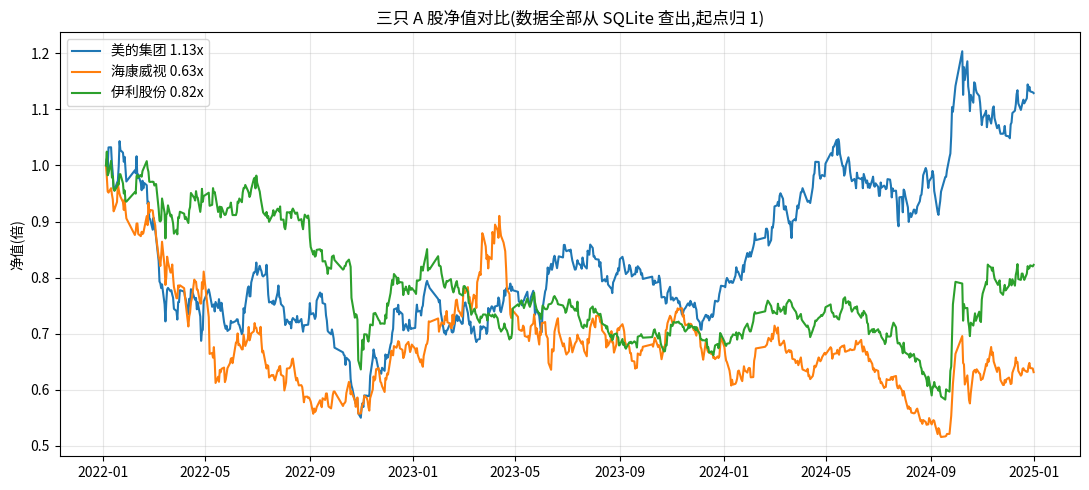

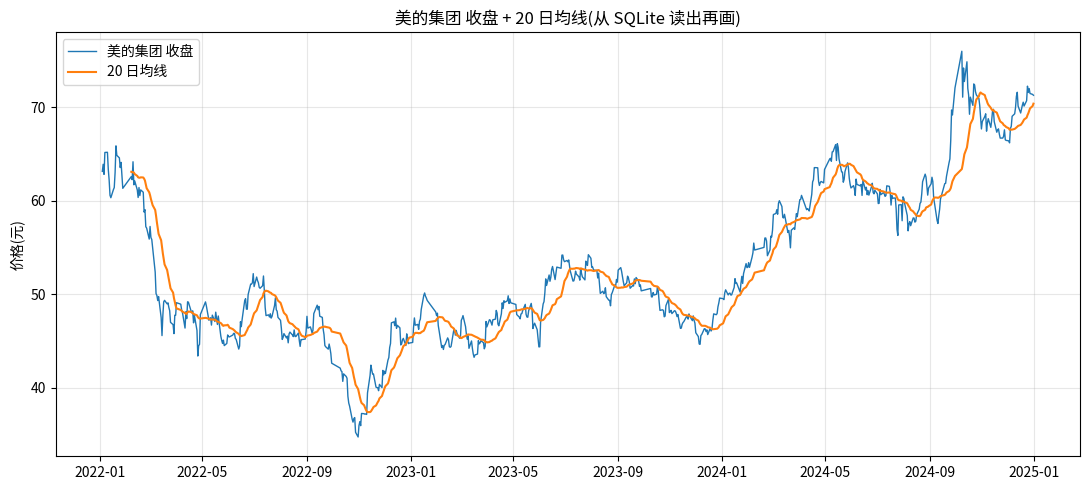

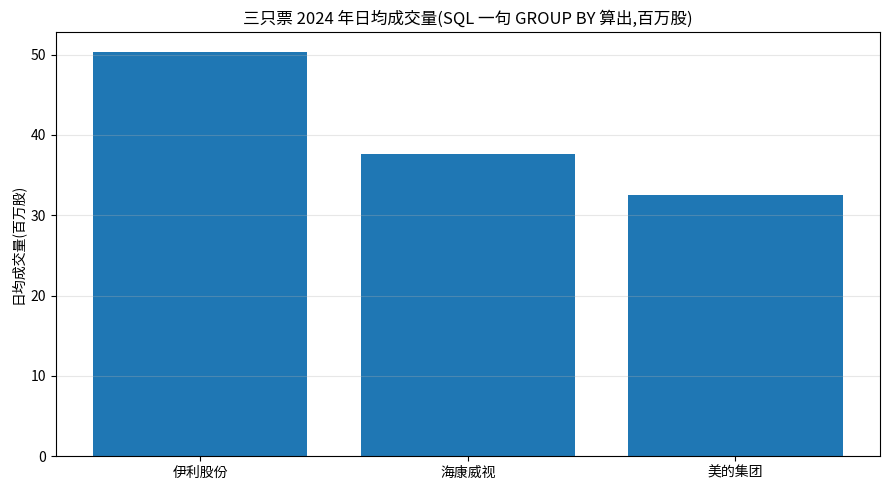

In [2]:
# day_045_sqlite.py — 把行情存进 SQLite:建表 / 写入 / 索引 / 查询
# 用真实 A 股(美的/海康/伊利)日线写进一个本地数据库文件,以后查数据一句话秒出
# 数据:baostock 日线(免费、国内零翻墙);存储:SQLite(Python 自带 sqlite3,零安装)
import time
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import baostock as bs

def _data_path(_name):
    # 铁律62:data/ 放在 notebook 文件夹里。仓库根(run_lab)存取 out/notebook/data/;
    # 原版 notebook 在 out/notebook/ 用 data/;中国版在 out/notebook/cn/ 用 ../data/
    from pathlib import Path as _P
    _here = _P.cwd()
    for _b in [_here/'data', _here/'..'/'data', _here/'out'/'notebook'/'data', _here/'..'/'..'/'data', _here/'..'/'..'/'..'/'data']:
        if (_b/_name).exists():
            return str(_b/_name)
    if (_here/'out'/'notebook').exists():
        _t = _here/'out'/'notebook'/'data'
    elif _here.name == 'cn':
        _t = _here/'..'/'data'
    else:
        _t = _here/'data'
    _t.mkdir(parents=True, exist_ok=True)
    return str(_t/_name)

pd.set_option('display.width', 160)
plt.rcParams['axes.unicode_minus'] = False

STOCKS = {'美的集团': 'sz.000333', '海康威视': 'sz.002415', '伊利股份': 'sh.600887'}
START, END = '2022-01-01', '2024-12-31'
DB_PATH = 'D045_market.db'

# ==== 0. 先拿行情:CSV 在就直接读,不在才用 baostock 拉再存成 CSV ====
print('==== 0. 拉三只不同行业的 A 股日线 ====')
import os as _os
_csv = _data_path('D045_sqlite.csv')
if _os.path.exists(_csv):
    market = pd.read_csv(_csv, dtype={'code': str})
    print(f'从本地 CSV 读取行情:{_csv}')
else:
    lg = bs.login()
    if lg.error_code != '0':
        raise RuntimeError(f'baostock 登录失败:{lg.error_msg}')
    frames = []
    for name, code in STOCKS.items():
        rs = bs.query_history_k_data_plus(code, 'date,code,open,high,low,close,volume',
                                          start_date=START, end_date=END, frequency='d', adjustflag='2')
        rows = []
        while rs.error_code == '0' and rs.next():
            rows.append(rs.get_row_data())
        one = pd.DataFrame(rows, columns=rs.fields)
        one['name'] = name
        frames.append(one)
    bs.logout()
    market = pd.concat(frames, ignore_index=True)
    market.to_csv(_csv, index=False)
    print(f'已从 baostock 拉取并存成 CSV:{_csv}')
for c in ['open', 'high', 'low', 'close', 'volume']:
    market[c] = pd.to_numeric(market[c])
print(f'共拉到 {len(market)} 行 × {market.shape[1]} 列,{market["name"].nunique()} 只股票')
print(market[['date', 'name', 'close', 'volume']].head(3).to_string(index=False))

# ==== 1. 建库 + 写入:一句 to_sql 把表存进 SQLite 文件 ====
print('\n==== 1. 把行情写进 SQLite(一个文件就是一个数据库)====')
if Path(DB_PATH).exists():
    Path(DB_PATH).unlink()
conn = sqlite3.connect(DB_PATH)
market.to_sql('daily', conn, if_exists='replace', index=False)
size_kb = Path(DB_PATH).stat().st_size / 1024
print(f'已写入表 daily,数据库文件 {DB_PATH} 大小约 {size_kb:.0f} KB(就这一个文件,装得下全部行情)')
schema = pd.read_sql('PRAGMA table_info(daily)', conn)
print('表 daily 的列结构(数据库知道每一列叫什么、是什么类型):')
print(schema[['name', 'type']].to_string(index=False))

# ==== 2. 查询:一句 SQL 把某只票某段时间取出来 ====
print('\n==== 2. 一句话把美的集团 2024 年的行情查出来 ====')
Q = ("SELECT date, name, close, volume FROM daily "
     "WHERE name='美的集团' AND date>='2024-01-01' ORDER BY date")
midea = pd.read_sql(Q, conn)
print(f'查到 {len(midea)} 行,前 3 行:')
print(midea.head(3).to_string(index=False))

# ==== 3. 索引:给查询装个目录(像书末的目录),大表也能秒查 ====
print('\n==== 3. 建索引前后,查询速度对比 ====')
def timeit(sql, repeat=300):
    t0 = time.perf_counter()
    for _ in range(repeat):
        pd.read_sql(sql, conn)
    return (time.perf_counter() - t0) / repeat * 1000  # 毫秒/次
ms_before = timeit(Q)
conn.execute('CREATE INDEX idx_name_date ON daily(name, date)')
ms_after = timeit(Q)
print(f'没索引:{ms_before:.2f} 毫秒/次  →  建索引后:{ms_after:.2f} 毫秒/次')
print('数据小,差别不明显;几十万行的大表上,索引能把查询从几秒压到几毫秒')

# ==== 4. 从数据库取三只票,画净值对比(证明数据完好取回)====
print('\n==== 4. 从 SQLite 取三只票,画净值对比图 ====')
fig, ax = plt.subplots(figsize=(11, 5))
navs = {}
for name in STOCKS:
    one = pd.read_sql(f"SELECT date, close FROM daily WHERE name='{name}' ORDER BY date", conn)
    one['date'] = pd.to_datetime(one['date'])
    nv = one['close'] / one['close'].iloc[0]
    navs[name] = round(float(nv.iloc[-1]), 2)
    ax.plot(one['date'], nv, label=f'{name} {nv.iloc[-1]:.2f}x')
print('三只票区间净值(起点归1):', navs)
ax.set_title('三只 A 股净值对比(数据全部从 SQLite 查出,起点归 1)')
ax.set_ylabel('净值(倍)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('nv.png', dpi=120)

# ==== 5. 单只票收盘 + 20 日均线(同样从库里取出再算)====
print('\n==== 5. 单只票收盘 + 20 日均线(从库里读出再画)====')
m2 = pd.read_sql("SELECT date, close FROM daily WHERE name='美的集团' ORDER BY date", conn)
m2['date'] = pd.to_datetime(m2['date'])
m2['ma20'] = m2['close'].rolling(20).mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(m2['date'], m2['close'], label='美的集团 收盘', lw=1)
ax.plot(m2['date'], m2['ma20'], label='20 日均线', lw=1.5)
ax.set_title('美的集团 收盘 + 20 日均线(从 SQLite 读出再画)')
ax.set_ylabel('价格(元)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('ma.png', dpi=120)

# ==== 6. SQL 也能直接做聚合:一句 GROUP BY 算每只票日均成交量 ====
print('\n==== 6. SQL 分组聚合:每只票 2024 年日均成交量 ====')
agg = pd.read_sql("SELECT name, AVG(volume)/1e6 AS avg_vol_mn FROM daily "
                  "WHERE date>='2024-01-01' GROUP BY name ORDER BY avg_vol_mn DESC", conn)
print(agg.to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(agg['name'], agg['avg_vol_mn'])
ax.set_title('三只票 2024 年日均成交量(SQL 一句 GROUP BY 算出,百万股)')
ax.set_ylabel('日均成交量(百万股)'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('vol.png', dpi=120)

conn.close()
print('\n[done] 行情已存进 SQLite,建表 / 写入 / 索引 / 查询全跑通,3 张图已生成')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | sz.000333 / sz.002415 / sh.600887 | 把美的、海康、伊利三只票多年日线写进一个 SQLite 文件,以后研究直接读文件不再联网 |
| 本地缓存 |  | 每天收盘把当天行情追加进库,积累成自己的本地行情库,回测随取随用 |
| 快速查询 |  | 一句 SQL 取某票某段区间;在(股票, 日期)上建索引,几十万行也能毫秒级查出 |
| SQL 聚合 |  | 用一句 GROUP BY 直接在数据库里算每只票的日均成交量,不用先全读出来再算 |


## 常见坑

### ⚠ 01. 大表不建索引,查询慢成蜗牛

几十万上百 万行的表,如果按股票、日期查却没在这些列上建索引,数据库只能从头扫到尾,一次查询可能要好几秒。规矩做法是:常用来过滤的列(通常是股票代码 + 日期)一定要建索引,查询立刻提速。

### ⚠ 02. 重复写入没想清楚 append 还是 replace

to_sql 有个 if_exists 参数:replace 是把整张表清掉重写,append 是往后追加。每天更新数据想追加却写成 replace,会把历史全删掉只剩今天;想重建却写成 append,会写进一堆重复行。先想清楚这次是重建还是追加。

### ⚠ 03. 日期存成乱格式,排序就会出错

日期最好统一存成『2024-01-05』这种年-月-日、前面补零的字符串,这样按字符排序正好等于按时间排序。如果存成『2024-1-5』或者各种杂格式,排序、区间筛选都会出乱子。存之前把日期格式统一好。

### ⚠ 04. 多个程序同时往一个库里写,会打架

SQLite 是单文件,擅长『一个人写、很多人读』。如果你开好几个程序同时往同一个库写,可能会互相锁住报错。个人研究一般用不到并发写;真要多人高并发,就该考虑下面说的更大的数据库了。

### ⚠ 05. 数据涨到上 GB,SQLite 就吃力了

SQLite 胜在轻便,适合个人研究这种从几兆到几百兆的数据。但当你的库涨到好几 GB、或者要很多人同时高频读写时,它就开始吃力。这时候该升级到 PostgreSQL、MySQL 这类专门的数据库服务器。先用 SQLite 起步,需要了再换,不要一上来就上重武器。

## 实战 SOP · 用 SQLite 存行情的几条规矩

1. 常用来过滤的列(股票代码 + 日期)一定要建索引,否则大表查询慢
2. 想清楚每次写入是重建(replace)还是追加(append),别把历史删了或写重复
3. 日期统一存成 2024-01-05 这种补零的年-月-日字符串,排序筛选才不出错
4. 个人研究小数据用 SQLite 足够;上 GB 或要高并发就换 PostgreSQL/MySQL
5. 查询用 pandas 的 read_sql,结果直接是 DataFrame,跟后续画图算因子无缝衔接

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 数据库就是一个又能装、又好查的超级仓库;SQLite 是其中最轻便的,一个文件就是一个数据库,Python 自带、零安装。
3. 一句 to_sql 把 DataFrame 行情表写进数据库;关机也不丢,以后查数据不用再联网。
4. 查询用 SQL(读起来像大白话的 SELECT … FROM … WHERE …),read_sql 把结果直接变回 DataFrame。
5. 索引就是给查询装的目录:在(股票, 日期)上建索引,大表查询从几秒压到几毫秒。
6. SQL 还能直接做聚合(GROUP BY),不用先全读出来再算,数据库帮你算好。
7. SQLite 适合个人研究的小数据;上 GB 或高并发时,升级到 PostgreSQL/MySQL。

## 自测题

**Q1.** SQLite 和需要装服务器的数据库相比,最大的省心之处是什么?(提示:一个文件 / 零安装 / Python 自带)

**Q2.** 为什么在(股票, 日期)上建索引能让查询变快?用『书的目录』打个比方说说看。

**Q3.** to_sql 的 if_exists 写成 replace 和 append,分别会发生什么?每天更新数据该用哪个?

**Q4.** 什么情况下你应该考虑从 SQLite 升级到 PostgreSQL 这类更大的数据库?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 046 · 完整流水线:数据→分析→图** (End-to-End Pipeline)

学会了拉数据、存数据,下一节我们把前面学的零散本事串成一条完整的流水线:封装成一个能一键运行的小程序,数据自动拉、自动清洗、自动分析、自动出图,换只股票整条线重跑,告别每次复制粘贴一团乱。

## 推荐阅读

- Kreibich《Using SQLite》(2010/O'Reilly)— 一本把 SQLite 讲透的入门书,从建表到索引深入浅出。
- Beaulieu《Learning SQL》(2020/O'Reilly)— 零基础学 SQL 查询语言的经典,读完就会写 SELECT/WHERE/GROUP BY。
- McKinney《Python for Data Analysis》(2022/O'Reilly)— pandas 之父的书,有专门一章讲 read_sql/to_sql 和数据库交互。
- SQLite 官方文档 When To Use SQLite(sqlite.org)— 官方给的『什么时候适合用 SQLite、什么时候不适合』权威清单。
- Hilpisch《Python for Finance》(2018/O'Reilly)— 量化视角讲如何把金融数据落地存储与高效读取,有数据库相关实战。